# E-Commerce Customer Analytics
## Phase 1 — Exploratory Data Analysis (EDA)
**Dataset:** Olist Brazilian E-Commerce  
**Goal:** Understand the structure, quality, and key patterns in the data before cleaning and modeling.

### What is EDA?
Exploratory Data Analysis is the first step in any data project. Before building models or dashboards,
we need to deeply understand what the data contains, how it's structured, where it has issues,
and what patterns or stories are already visible. Think of it as getting to know your data.

---
## 1. Import Libraries
We load all the Python libraries we'll need upfront. This is standard practice — it makes dependencies
immediately visible to anyone reading the notebook.

In [10]:
# pandas: core library for data manipulation and analysis (DataFrames, groupby, merge, etc.)
import pandas as pd

# numpy: numerical computing — used for array operations and math functions
import numpy as np

# matplotlib: base plotting library — seaborn builds on top of it
import matplotlib.pyplot as plt

# seaborn: statistical visualization library — cleaner, higher-level charts than raw matplotlib
import seaborn as sns

# os: interact with the operating system (file paths, directory checks)
import os

# warnings: suppress non-critical warnings to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style for all charts throughout the notebook
# 'whitegrid' adds subtle horizontal grid lines which help read values
# 'muted' uses soft, professional colors — good for portfolio work
sns.set_theme(style='whitegrid', palette='muted')

# Set a default figure size so all charts are consistently sized
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully ✅')

import os

# Build the absolute path to the project root dynamically
# This works regardless of where the notebook is opened from
PROJECT_ROOT = os.path.expanduser('~/Desktop/ecommerce-customer-analytics')
DOCS_PATH = os.path.join(PROJECT_ROOT, 'docs')
RAW_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw') + '/'

# Create the docs folder if it doesn't exist yet
os.makedirs(DOCS_PATH, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Docs path:    {DOCS_PATH}')
print(f'Raw data path:{RAW_PATH}')
print('Paths configured ✅')

Libraries loaded successfully ✅
Project root: /Users/omartouzani/Desktop/ecommerce-customer-analytics
Docs path:    /Users/omartouzani/Desktop/ecommerce-customer-analytics/docs
Raw data path:/Users/omartouzani/Desktop/ecommerce-customer-analytics/data/raw/
Paths configured ✅


---
## 2. Load the Datasets
The Olist dataset is a **relational dataset** — it's split across multiple CSV files that can be
joined together using shared ID columns (like `order_id`, `customer_id`, `product_id`).
We load each file into its own DataFrame and will merge them as needed throughout the analysis.

In [2]:
RAW_PATH = '~/Desktop/ecommerce-customer-analytics/data/raw/'

# Load each dataset into a separate DataFrame
# Each file represents a different 'table' in the e-commerce database

# Core order information (status, timestamps, customer ID)
orders = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')

# Line items within each order (product ID, price, freight, seller ID)
order_items = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')

# Payment details per order (method, installments, value)
payments = pd.read_csv(RAW_PATH + 'olist_order_payments_dataset.csv')

# Customer reviews per order (score, comment title, comment message)
reviews = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')

# Customer information (unique ID, city, state, zip code)
customers = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')

# Seller information (ID, city, state, zip code)
sellers = pd.read_csv(RAW_PATH + 'olist_sellers_dataset.csv')

# Product catalog (ID, category, dimensions, weight, photos count)
products = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')

# Translates Portuguese category names to English
# Important since the products table uses Portuguese names by default
category_tr = pd.read_csv(RAW_PATH + 'product_category_name_translation.csv')

print('All datasets loaded successfully ✅')

All datasets loaded successfully ✅


---
## 3. Dataset Overview
Before doing any analysis, we take a high-level look at each table.
We want to know: how many rows and columns does each table have? What are the column names?
This helps us understand the overall scale of the dataset and plan which tables to join.

In [3]:
# Store all datasets in a dictionary so we can loop over them cleanly
# This avoids repeating the same code for each individual DataFrame
datasets = {
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'category_translation': category_tr
}

# Loop through each dataset and print its shape and column names
# df.shape returns (rows, columns)
# df.columns returns the list of column names
for name, df in datasets.items():
    print(f'\n{"-"*50}')
    print(f'📦 {name.upper()} — Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')


--------------------------------------------------
📦 ORDERS — Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--------------------------------------------------
📦 ORDER_ITEMS — Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--------------------------------------------------
📦 PAYMENTS — Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--------------------------------------------------
📦 REVIEWS — Shape: (99224, 7)
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--------------------------------------------------
📦 CUSTOMERS — Shape: (99441, 5)
Columns: ['cus

---
## 4. Missing Values Analysis
Missing values are one of the most common data quality issues. If we don't handle them properly,
they can silently break our analysis or produce misleading results.

Here we identify exactly which columns have missing values and how severe the problem is,
so we can plan how to handle them in the Data Cleaning phase.

In [4]:
# Define a reusable function to summarize missing values for any DataFrame
# A function is better here than repeating the same code 8 times
def missing_summary(df, name):
    # Count null values per column
    missing = df.isnull().sum()
    
    # Calculate what percentage of rows are missing per column
    # This is more useful than raw counts since tables have different sizes
    pct = (missing / len(df) * 100).round(2)
    
    # Combine into a single summary DataFrame
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    
    # Only show columns that actually have missing values (filter out zeros)
    # Sort by worst offenders first
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    if summary.empty:
        print(f'\n✅ {name}: No missing values')
    else:
        print(f'\n⚠️  {name}:')
        print(summary.to_string())

# Run the function for every dataset
for name, df in datasets.items():
    missing_summary(df, name)


⚠️  orders:
                               Missing Count  Missing %
order_delivered_customer_date           2965       2.98
order_delivered_carrier_date            1783       1.79
order_approved_at                        160       0.16

✅ order_items: No missing values

✅ payments: No missing values

⚠️  reviews:
                        Missing Count  Missing %
review_comment_title            87656      88.34
review_comment_message          58247      58.70

✅ customers: No missing values

✅ sellers: No missing values

⚠️  products:
                            Missing Count  Missing %
product_category_name                 610       1.85
product_name_lenght                   610       1.85
product_description_lenght            610       1.85
product_photos_qty                    610       1.85
product_weight_g                        2       0.01
product_length_cm                       2       0.01
product_height_cm                       2       0.01
product_width_cm                    

---
## 5. Orders Analysis
The `orders` table is the central table of this dataset — everything connects to it.
We start by understanding the lifecycle of orders: their statuses, volume trends over time,
and when customers tend to place orders.

### 5a. Order Status Distribution
Each order has a status (delivered, shipped, cancelled, etc.).
Understanding this distribution tells us how healthy the fulfillment pipeline is
and how much of our data represents completed transactions.

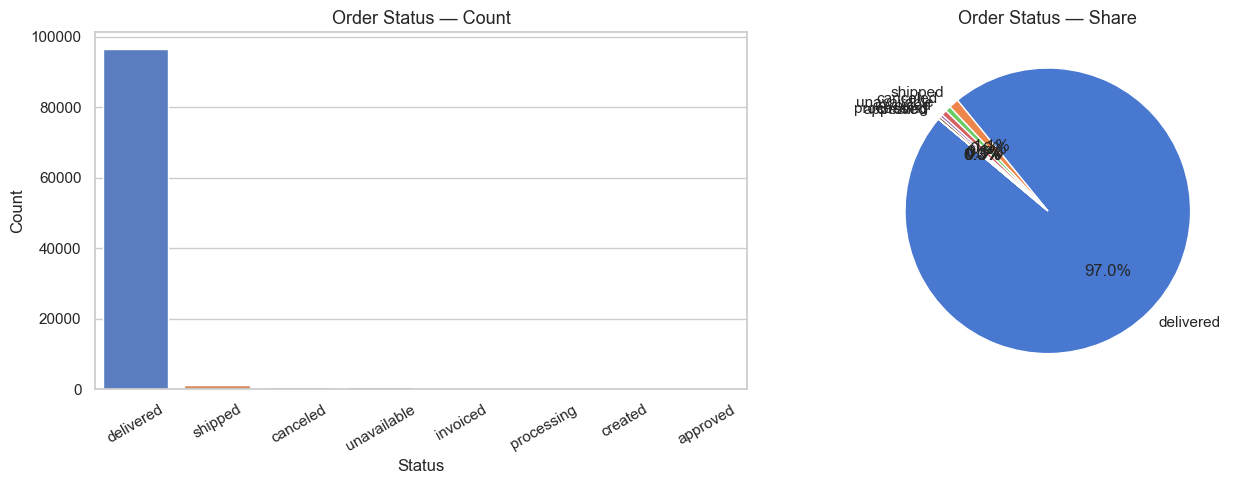


Order Status Summary:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [12]:
# Count how many orders exist for each status
# value_counts() automatically sorts from most to least frequent
status_counts = orders['order_status'].value_counts()

# Create a side-by-side layout: bar chart on the left, pie chart on the right
# This gives both absolute counts and relative proportions at a glance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart for absolute counts ---
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='muted')
axes[0].set_title('Order Status — Count', fontsize=13)
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
# Rotate labels so they don't overlap each other
axes[0].tick_params(axis='x', rotation=30)

# --- Right: Pie chart for percentage share ---
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Order Status — Share', fontsize=13)

plt.tight_layout()
# Save chart to docs/ folder for use in the README and portfolio
plt.savefig(os.path.join(DOCS_PATH, 'order_status_distribution.png'), dpi=150)
plt.show()

print('\nOrder Status Summary:')
print(status_counts)

### 5b. Orders Over Time
A time series of order volume helps us spot growth trends, seasonal patterns,
and any anomalies (sudden spikes or drops) worth investigating further.

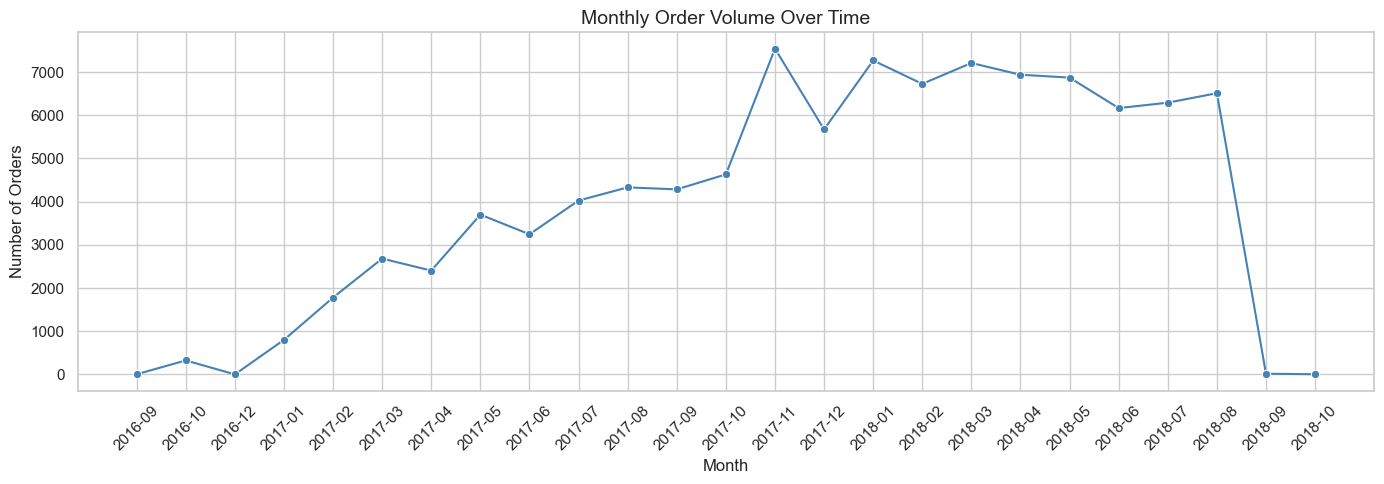

In [13]:
# Convert the purchase timestamp from string to datetime format
# This is essential — without it pandas treats dates as plain text and can't do time-based grouping
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Create a year-month column (e.g. '2017-01') for monthly grouping
# dt.to_period('M') extracts the month period from a datetime column
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month and reset index so year_month becomes a regular column
monthly_orders = orders.groupby('year_month').size().reset_index(name='order_count')

# Convert Period type back to string for plotting (seaborn doesn't handle Period natively)
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

plt.figure(figsize=(14, 5))
# Line chart with markers at each data point — better than a bar chart for showing trends over time
sns.lineplot(data=monthly_orders, x='year_month', y='order_count', marker='o', color='steelblue')
plt.title('Monthly Order Volume Over Time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'monthly_order_volume.png'), dpi=150)
plt.show()

### 5c. Orders by Day of Week & Hour
Understanding WHEN customers shop gives us behavioral insight.
This is useful for marketing (when to run promotions) and operations (when to expect peak load).

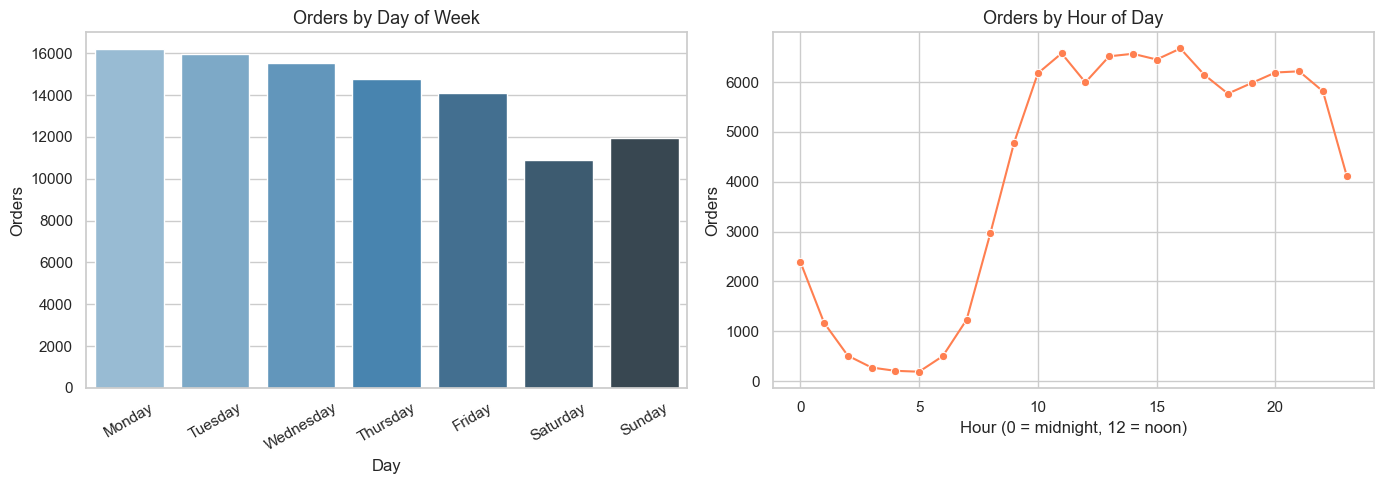

In [15]:
# Extract day of week name (e.g. 'Monday') from the timestamp
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

# Extract hour of day (0-23) from the timestamp
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

# Define the correct day ordering for the chart
# value_counts() sorts by frequency, not weekday order — we fix that with reindex()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = orders['day_of_week'].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Orders by day of week ---
# Blues_d is a dark-to-light blue palette — gives a visually clean result for bar charts
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Orders by Day of Week', fontsize=13)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=30)

# --- Right: Orders by hour of day ---
# Sort by hour index (0-23) to get chronological order
hour_counts = orders['hour'].value_counts().sort_index()
# Line chart is ideal here — it shows the continuous rhythm of the day
sns.lineplot(x=hour_counts.index, y=hour_counts.values, ax=axes[1], marker='o', color='coral')
axes[1].set_title('Orders by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour (0 = midnight, 12 = noon)')
axes[1].set_ylabel('Orders')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'orders_day_hour.png'), dpi=150)
plt.show()

---
## 6. Revenue Analysis
Revenue is the most important business metric. We analyze the distribution of order values
to understand typical spend, identify outliers, and see which payment methods customers prefer.

Note: Currency is Brazilian Real (BRL). 1 BRL ≈ 0.20 USD.

Revenue Summary (BRL):
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: total_revenue, dtype: float64


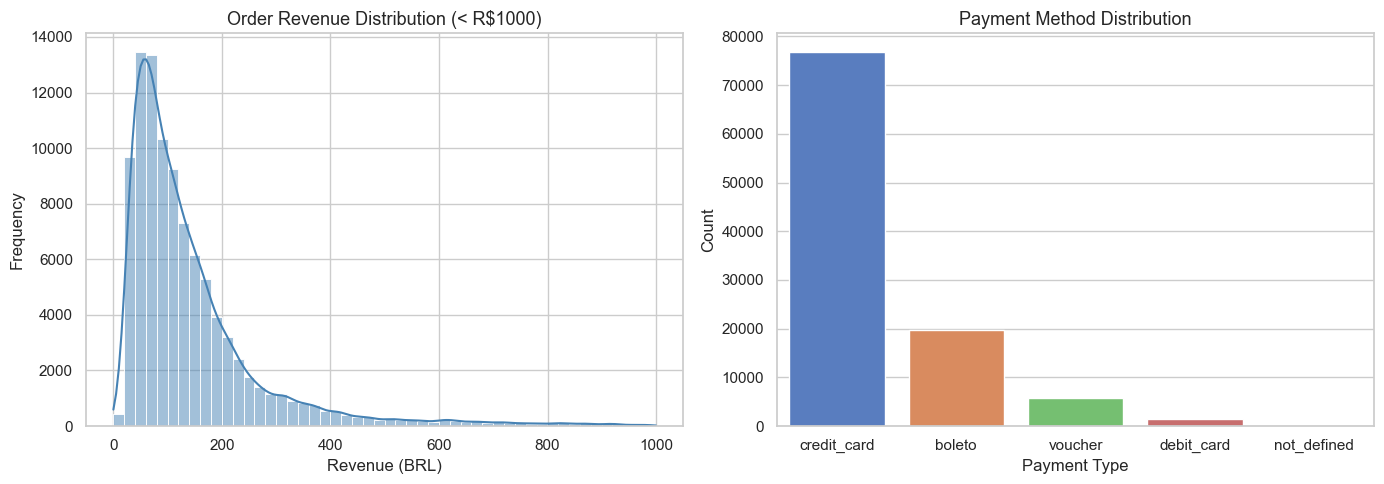

In [16]:
# Some orders have multiple payment rows (e.g. split payments or installments)
# We sum all payment rows per order to get the true total order value
order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'total_revenue']

# describe() gives a statistical summary: count, mean, std, min, quartiles, max
# This immediately reveals the spread of order values and any extreme outliers
print('Revenue Summary (BRL):')
print(order_revenue['total_revenue'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Revenue distribution histogram ---
# We cap at R$1000 to remove extreme outliers from the visual
# Outliers still exist in the data — we're just excluding them from this chart for clarity
# kde=True overlays a smoothed density curve on top of the histogram
sns.histplot(
    order_revenue[order_revenue['total_revenue'] < 1000]['total_revenue'],
    bins=50, ax=axes[0], color='steelblue', kde=True
)
axes[0].set_title('Order Revenue Distribution (< R$1000)', fontsize=13)
axes[0].set_xlabel('Revenue (BRL)')
axes[0].set_ylabel('Frequency')

# --- Right: Payment method breakdown ---
# Understanding how customers pay helps with checkout optimization and fraud detection
payment_types = payments['payment_type'].value_counts()
sns.barplot(x=payment_types.index, y=payment_types.values, ax=axes[1], palette='muted')
axes[1].set_title('Payment Method Distribution', fontsize=13)
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'revenue_analysis.png'), dpi=150)
plt.show()

---
## 7. Product Analysis
Understanding which product categories drive the most orders helps identify
what the business is best at and where growth opportunities might exist.

We need to join three tables here:
- `order_items` → tells us which products were ordered
- `products` → tells us each product's category (in Portuguese)
- `category_tr` → translates category names to English

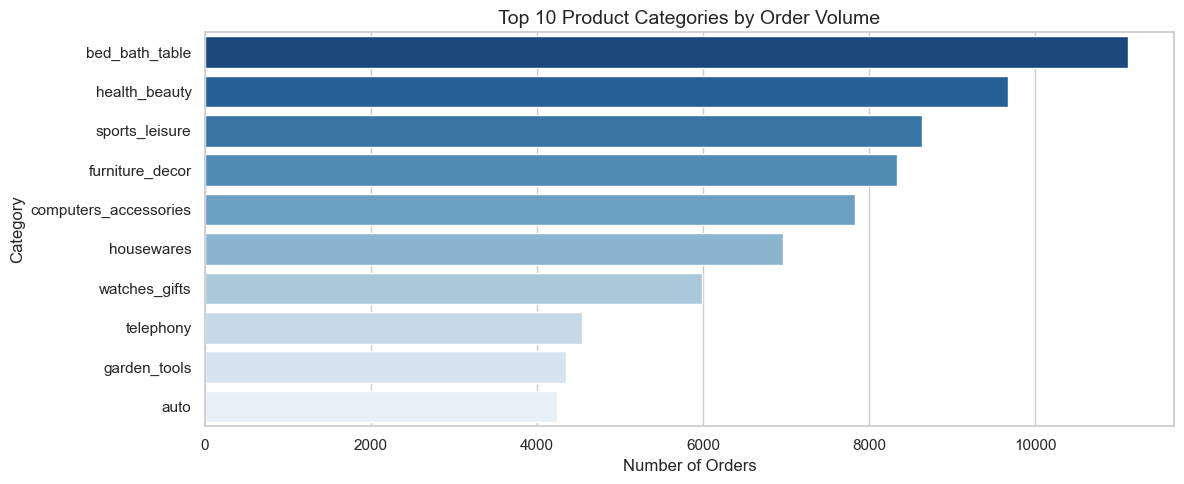

In [18]:
# Step 1: Add English category names to the products table
# We do a LEFT JOIN — keep all products even if they have no English translation
products_en = products.merge(category_tr, on='product_category_name', how='left')

# Step 2: Join order_items with the enriched products table
# This gives us the category for each ordered item
# We only bring in the two columns we actually need to keep the DataFrame lean
items_products = order_items.merge(
    products_en[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Step 3: Count orders per category and take the top 10
# Each row in order_items represents one item ordered, so counting rows = counting order lines
top_categories = items_products['product_category_name_english'].value_counts().head(10)

# Horizontal bar chart is better than vertical here because category names are long
# Blues_r reverses the blue palette so the longest bar (top category) is darkest
plt.figure(figsize=(12, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')
plt.title('Top 10 Product Categories by Order Volume', fontsize=14)
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'top_categories.png'), dpi=150)
plt.show()

---
## 8. Customer Analysis
Understanding customer behavior is at the core of this project.
Two key questions here:
1. Do customers come back to buy again, or is it mostly one-time purchases?
2. Where are customers geographically concentrated?

The answers will directly inform our RFM segmentation in Phase 3.

Orders per Customer (frequency distribution):
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Customers with only 1 order: 93,099 (96.9%)


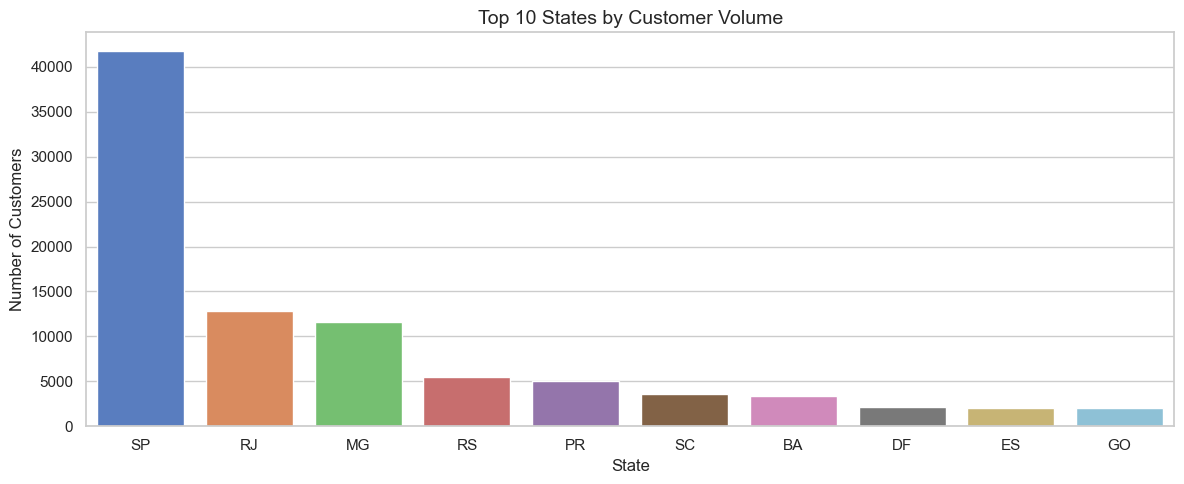

In [19]:
# Step 1: Join orders with customers to get the unique customer identifier
# Note: customer_id in the orders table is order-specific.
# customer_unique_id in the customers table is the true unique customer identifier
# (one person can have multiple customer_id values if they placed multiple orders)
orders_customers = orders.merge(customers, on='customer_id', how='left')

# Step 2: Count how many orders each unique customer placed
# groupby on customer_unique_id + size() counts rows (orders) per customer
customer_order_counts = orders_customers.groupby('customer_unique_id').size()

# Show the distribution of order frequency
# e.g. how many customers placed exactly 1, 2, 3, ... orders
print('Orders per Customer (frequency distribution):')
print(customer_order_counts.value_counts().head(10))

# Calculate what proportion of customers only ever bought once
# This is a critical insight — a high one-time buyer rate means low retention
# and signals opportunity for loyalty/re-engagement campaigns
one_time = (customer_order_counts == 1).sum()
one_time_pct = (customer_order_counts == 1).mean() * 100
print(f'\nCustomers with only 1 order: {one_time:,} ({one_time_pct:.1f}%)')

# Step 3: Geographic distribution — which Brazilian states have the most customers?
# This tells us where the business is strongest geographically
top_states = customers['customer_state'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette='muted')
plt.title('Top 10 States by Customer Volume', fontsize=14)
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'customers_by_state.png'), dpi=150)
plt.show()

---
## 9. Review Score Analysis
Customer satisfaction scores are a direct signal of product and service quality.
A skewed distribution (lots of 1s or lots of 5s) tells a very different story
than a normal distribution centered around 3.

This will also be a useful feature when we build our predictive model later.

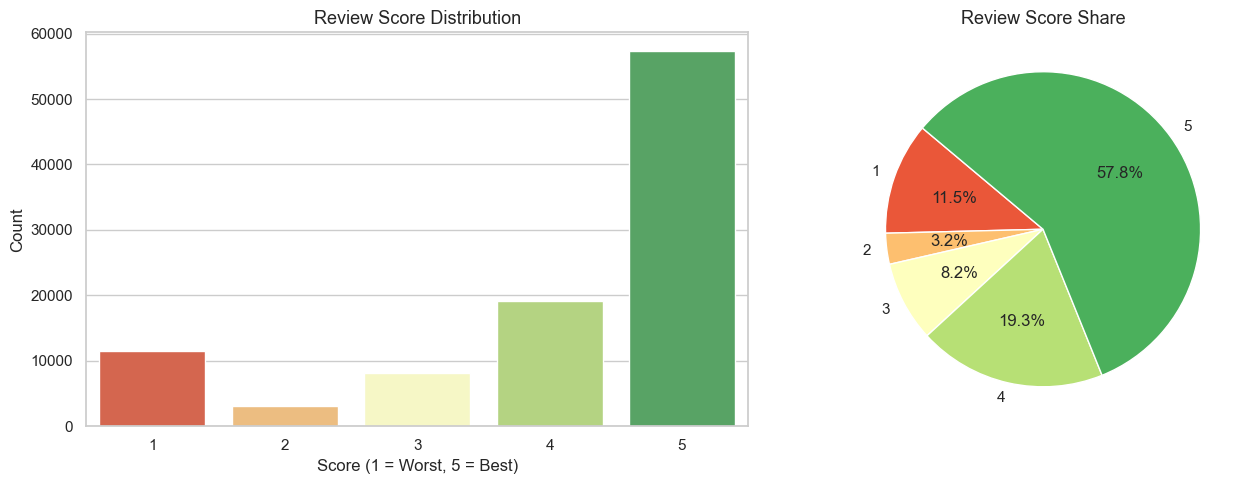

Average Review Score: 4.09 / 5.00


In [20]:
# Count how many reviews exist for each score (1 through 5)
# sort_index() ensures scores appear in order 1, 2, 3, 4, 5 rather than by frequency
review_scores = reviews['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart ---
# RdYlGn is a Red-Yellow-Green diverging palette
# Red = low scores (1-2), Yellow = neutral (3), Green = high scores (4-5)
# This color mapping intuitively communicates satisfaction levels
sns.barplot(x=review_scores.index, y=review_scores.values, ax=axes[0], palette='RdYlGn')
axes[0].set_title('Review Score Distribution', fontsize=13)
axes[0].set_xlabel('Score (1 = Worst, 5 = Best)')
axes[0].set_ylabel('Count')

# --- Right: Pie chart for percentage share ---
axes[1].pie(
    review_scores.values,
    labels=review_scores.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('RdYlGn', 5),
    startangle=140
)
axes[1].set_title('Review Score Share', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'review_scores.png'), dpi=150)
plt.show()

# Print the average score as a single summary metric
print(f'Average Review Score: {reviews["review_score"].mean():.2f} / 5.00')

---
## 10. EDA Summary & Key Findings
We conclude the EDA phase by printing a clean summary of the most important
numbers from the dataset. This becomes the basis for our README and portfolio writeup.

After this phase, we move to **Phase 2 — Data Cleaning**, where we will:
- Handle missing values based on what we found here
- Fix data types (especially date columns)
- Merge tables into a single clean analytical table
- Remove duplicates and outliers where appropriate

In [21]:
# Print a clean summary of key metrics from the entire dataset
# These numbers give a quick business snapshot of the Olist platform
print('=' * 55)
print('EDA SUMMARY — OLIST E-COMMERCE DATASET')
print('=' * 55)

# Total unique orders in the dataset
print(f'Total Orders:          {len(orders):,}')

# Unique customers (using customer_unique_id, not customer_id)
print(f'Total Customers:       {customers["customer_unique_id"].nunique():,}')

# Unique products in the catalog
print(f'Total Products:        {products["product_id"].nunique():,}')

# Unique sellers on the platform
print(f'Total Sellers:         {sellers["seller_id"].nunique():,}')

# Total platform revenue (sum of all payment values)
print(f'Total Revenue (BRL):   R${payments["payment_value"].sum():,.2f}')

# Average value per order
print(f'Avg Order Value (BRL): R${order_revenue["total_revenue"].mean():,.2f}')

# Customer satisfaction score out of 5
print(f'Avg Review Score:      {reviews["review_score"].mean():.2f} / 5')

# Date range covered by the dataset
print(f'Date Range:            {orders["order_purchase_timestamp"].min().date()} to {orders["order_purchase_timestamp"].max().date()}')

print('=' * 55)
print('\n✅ EDA complete. Proceed to Phase 2 — Data Cleaning.')

EDA SUMMARY — OLIST E-COMMERCE DATASET
Total Orders:          99,441
Total Customers:       96,096
Total Products:        32,951
Total Sellers:         3,095
Total Revenue (BRL):   R$16,008,872.12
Avg Order Value (BRL): R$160.99
Avg Review Score:      4.09 / 5
Date Range:            2016-09-04 to 2018-10-17

✅ EDA complete. Proceed to Phase 2 — Data Cleaning.
